# **MET Computer Vision with Deep Learning**
## Visual Recognition
## Lab1 - Image classification using the Bag of Visual Words Model

2021-24 - Veronica Vilaplana - [GPI @ IDEAI](https://imatge.upc.edu/web/) Research group // [ETSETB – UPC.TelecosBCN](https://telecos.upc.edu/ca)

The goal of this laboratory work is to solve an image classification problem using the Bag of Visual Words model for image representation.


We will learn how to
1.   Detect and describe keypoints using SIFT
2.   Create a dictionary of visual words
3.   Represent an image with a histogram of visual words
4.   Train and test an image classifier based on the BOW representation

In the first part of this notebook code is provided to solve the task using SIFT keypoints and a k-NN classifier.

Then, you will have to complete some tasks, changing some of the hyperparemeters, computing other metrics or using a different classifier.

Instructions:
1. You can work in teams of two.
2. <font color=blue>**There are four mandatory tasks (required to pass the assignment) and one optional task (for extra credit).**</font>
3. Add and run your Python code and answer the questions in this same notebook.
5. Upload a zip file with the notebook (after running code cells, including results, confussion matrices, images, etc.) to Atenea.

---

### Write here your names

**Name1**: Enric Rubio Pacho

**Name2**: Agnès Felip i Díaz

---

We will use a dataset of images and files with image names of the images for the training and test splits.

First, download from ATENEA the file BOW_data.zip. Upload it to the Colab notebook using the menu on the left.

You could also copy the file to your Google drive and mount your drive in the colaboratory environment using:
>from google.colab import drive

>drive.mount('/content/drive')


Unzip the file:

In [35]:
# !unzip BOW_data.zip

In [36]:
import pickle

import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
   

We read the train and test image names and labels

In [37]:
def load_files(): 
    train_filenames = pickle.load(open('./BOW_data/train_filenames.dat','rb'))
    test_filenames = pickle.load(open('./BOW_data/test_filenames.dat','rb'))
    train_labels = pickle.load(open('./BOW_data/train_labels.dat','rb'))
    test_labels = pickle.load(open('./BOW_data/test_labels.dat','rb'))

    return train_filenames, test_filenames, train_labels, test_labels

In [38]:
filenames, test_filenames, train_labels, test_labels = load_files()

In [39]:
def cv2_imshow(img):
    # Assuming 'img' is a valid image array
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")  # optional: hides axis ticks
    plt.show()

We will detect and describe keypoints using SIFT

But before creating the dictionary, let's compute and display the keypoints for a single sample image

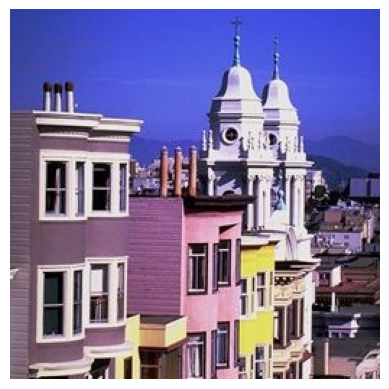

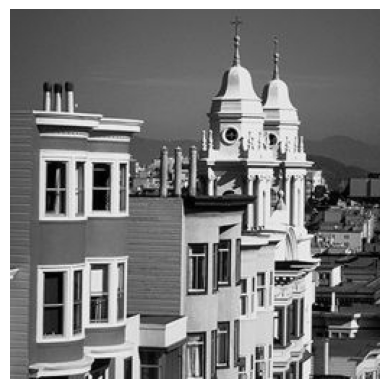

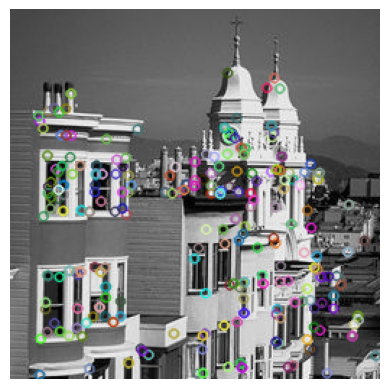

In [40]:
img = cv2.imread('./BOW_data/train/inside_city/a48009.jpg')
cv2_imshow(img)

gray= cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

#SIFTdetector = cv2.xfeatures2d.SIFT_create(nfeatures=300)

SIFTdetector = cv2.SIFT_create(300)
kpt=SIFTdetector.detect(gray,None)
img2=cv2.drawKeypoints(gray,kpt,img)
cv2_imshow(img)

Now we start to create the dictionary of visual words by detecting keypoints and computing the SIFT descriptors for all the training images

In [41]:
def compute_SIFT_descriptors(train_filenames, train_labels, detector, mode):
    Train_descriptors = []
    Train_label_per_descriptor = []
    for filename, labels in zip(train_filenames, train_labels):
        ima = cv2.imread('./BOW_data/' + filename)
        gray = cv2.cvtColor(ima, cv2.COLOR_BGR2GRAY)
        
        if mode == 'dense':
            step_size = 10
            keypoints = [cv2.KeyPoint(x, y, 16) for y in range(0, gray.shape[0], step_size) 
                                               for x in range(0, gray.shape[1], step_size)]
            
            _, des = detector.compute(gray, keypoints)
        else:
            _, des = detector.detectAndCompute(gray, None)
         
        Train_descriptors.append(des)
        Train_label_per_descriptor.append(labels)
    
    D = np.vstack(Train_descriptors)
    return Train_descriptors, D

In [42]:
detector = cv2.SIFT_create(300)
descriptors, D = compute_SIFT_descriptors(filenames, train_labels, detector, 'keypoints_detection')

Next, we apply k-means clustering on the descriptor space. The cluster centers form the dictionary of visual words.

We will use `MiniBatchKMeans`, a variant of the KMeans algorithm which uses mini-batches to reduce the computation time.

`n_clusters` is the number of clusters or visual words in the dictionary. You can change this value to see the efect of using bigger or smaller dictionaries.

In [43]:
def fit_KMeans(D, n_clusters=100, verbose=False, compute_labels=False, reassignment_ratio=10**-4, random_state=42, n_init=3):
    """
    Fit KMeans to the data D.
    Parameters
    ----------
    D : array-like, shape (n_samples, n_features)
        Data to cluster.
    n_clusters : int, optional 
        The number of clusters to form as well as the number of centroids to generate.
        Default is 100.
    verbose : bool, optional
        Whether to print progress messages. Default is False.
    compute_labels : bool, optional
        Whether to compute labels for the data points. Default is False.
    reassignment_ratio : float, optional
        The fraction of points to reassign in each iteration. Default is 10^-4.
    random_state : int, optional
        Determines random number generation for centroid initialization. Use an int to make the randomness deterministic. Default is 42.
    n_init : int, optional
        Number of time the k-means algorithm will be run with different centroid seeds. Default is 3.
    Returns
    -------
    kmeans : object
        The fitted KMeans object.
    """
    kmeans =  MiniBatchKMeans(n_clusters=n_clusters, verbose=verbose, batch_size=n_clusters * 20, compute_labels=compute_labels, reassignment_ratio=reassignment_ratio, random_state=random_state, n_init=n_init)  
    kmeans.fit(D)
    return kmeans

In [44]:
n_clusters = 128
codebook = fit_KMeans(D, n_clusters=n_clusters)
codebook.cluster_centers_

array([[ 29.823593 ,  33.98231  ,  16.700855 , ...,   4.18162  ,
          3.3001378,   7.592229 ],
       [ 25.54786  ,  36.628334 ,  25.807785 , ...,  59.619366 ,
         18.519224 ,   8.485434 ],
       [ 40.90836  ,  19.902716 ,  11.549851 , ...,  25.977716 ,
         18.218473 ,  16.198988 ],
       ...,
       [ 80.60404  ,  25.7575   ,   7.533892 , ...,  14.454125 ,
         15.622762 ,   9.060712 ],
       [ 21.908371 ,  19.953964 ,  18.322897 , ...,   6.902474 ,
          7.779766 ,  14.712195 ],
       [106.06851  ,  33.438457 ,   6.252037 , ...,  11.836403 ,
          9.209269 ,  12.609132 ]], dtype=float32)

In [45]:
def project_descriptors_to_visual_word(descriptors, codebook, n_clusters, scaler):
    """
    Project SIFT descriptors to visual words using the codebook.
    Parameters
    ----------
    descriptors : list of array-like, shape (n_samples, n_features)
        List of SIFT descriptors for each image.
    codebook : objectç
        The fitted KMeans object.
    Returns
    -------
    visual_words : array-like, shape (n_samples, n_clusters)
        The visual words for each image.
    """
    visual_words=np.zeros((len(descriptors),n_clusters),dtype=np.float32)
    for i in range(len(descriptors)):
        words=codebook.predict(descriptors[i])
        visual_words[i,:]=np.bincount(words,minlength=n_clusters)

    if scaler is not None:
        visual_words = scaler.fit_transform(visual_words)

    return visual_words

For each training image, we project each keypoint descriptor to its closest visual word. We represent each of the images with the frequency of each visual word.

In [46]:
visual_words = project_descriptors_to_visual_word(descriptors, codebook, n_clusters, None)

We create a k-nn classifier and train it with the training set histograms (Note that we use 'knn = KNeighborsClassifier`to create the classifier, and knn.fit for t

In [47]:
def classify(model, words, labels):
    model.fit(words, labels)

In [48]:
knn = KNeighborsClassifier(n_neighbors=5,n_jobs=-1,metric='euclidean')
classify(knn, visual_words, train_labels)

We compute the histograms for the test images, classify and compute the accuracy

In [49]:
def compute_histograms(filenames, codebook, n_clusters, scaler, detector, mode):
    """
    Compute histograms of visual words for each image.
    Parameters
    ----------
    filenames : list of str
        List of training image filenames.
    codebook : object
        The fitted KMeans object.
    Returns
    -------
    histograms : array-like, shape (n_samples, n_clusters)
        The histograms of visual words for each image.
    """
    histograms = np.zeros((len(filenames), n_clusters), dtype=np.float32)
    
    for i, filename in enumerate(filenames):
        img = cv2.imread('./BOW_data/' + filename)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        if mode == 'dense':
            step_size = 10
            keypoints = [cv2.KeyPoint(x, y, 16) for y in range(0, gray.shape[0], step_size) 
                                               for x in range(0, gray.shape[1], step_size)]
            
            _, des = detector.compute(gray, keypoints)
        else:
            _, des = detector.detectAndCompute(gray, None)
        
        words = codebook.predict(des)
        histograms[i, :] = np.bincount(words, minlength=n_clusters)

    if scaler is not None:
        histograms = scaler.transform(histograms)
    
    return histograms

In [50]:
visual_words_test = compute_histograms(test_filenames, codebook, n_clusters, None, detector, 'keypoints_detection')

In [51]:
print ('example of a histogram of visual words (representation of image i):')
print (visual_words_test[0,:])

example of a histogram of visual words (representation of image i):
[ 3.  0.  3.  1.  2.  4.  0.  4.  2.  0.  8.  1.  3.  4.  1.  1.  3.  0.
  1.  1.  1.  0.  0.  3.  0.  2.  0.  0.  2.  1.  2.  2.  8.  0.  2.  5.
  0.  2.  0.  3.  1.  1.  3.  0.  1.  2.  1.  4.  1.  0.  0.  1.  0.  2.
  0.  0.  0. 10.  4.  3.  0.  1.  2.  0.  2.  5.  5.  0.  0.  2.  2.  1.
  2.  7.  2.  3.  2.  2.  0.  7.  0.  0.  0.  2.  1.  3.  0.  3.  3.  3.
  3.  0.  2.  4.  1.  3.  3.  3.  5.  0.  2.  0.  1.  0.  2.  2.  2.  3.
  0.  1.  1.  1.  2.  8.  3.  0.  0.  1.  4.  0.  5.  1.  1.  3.  8.  0.
  1.  2.]


In [52]:
accuracy = 100*knn.score(visual_words_test, test_labels)
print(accuracy)

predicted_labels = knn.predict(visual_words_test)
accuracy2 = accuracy_score(test_labels, predicted_labels)
print(accuracy2)

54.15117719950434
0.5415117719950434


## Tasks



1. Compute the confusion matrix and balanced accuracy. Which are the easiest and the most difficult classes? (import confusion_matrix or plot_confusion_matrix and balanced_accuracy_score from sklearn.metrics)
2. Test different codebook sizes and different values of neighbors in k-NN. Compare and report your best results.
3. Use a linear SVM classifier (use sklearn StandardScaler to standardize features).
4. (Optional) Use another variant of SVM: (1) with RBF kernel, (2) with histogram intersection kernel.
Use sklearn `StandardScaler` to standardize features.
5. Use Dense SIFT instead of detected keypoints. Report your best results and compare with results using detected keypoints.
6. Conclusions: Write a few paragraphs summarizing your work, results and conclusions from this assignment






<font color=red>1.   Compute the confusion matrix and balanced accuracy. Which are the easiest and the most difficult classes?

Import `confusion_matrix` or `plot_confusion_matrix` and `balanced_accuracy_score` from sklearn.metrics)</font><br>

In [53]:

def compute_stats(labels, predicted): 
    conf_m = confusion_matrix(labels, predicted) 
    d = ConfusionMatrixDisplay(confusion_matrix=conf_m, display_labels=np.unique(labels))
    d.plot(xticks_rotation="vertical")
    plt.show()

    report = classification_report(labels, predicted) 
    print(report)
    
    balanced_acc = balanced_accuracy_score(labels, predicted)
    print(balanced_acc)

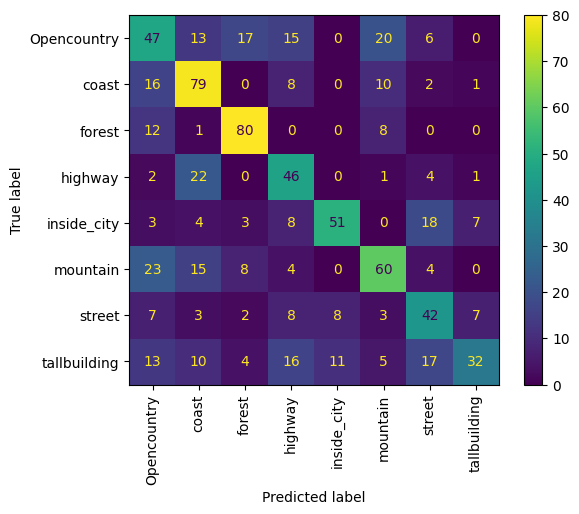

              precision    recall  f1-score   support

 Opencountry       0.38      0.40      0.39       118
       coast       0.54      0.68      0.60       116
      forest       0.70      0.79      0.74       101
     highway       0.44      0.61      0.51        76
 inside_city       0.73      0.54      0.62        94
    mountain       0.56      0.53      0.54       114
      street       0.45      0.53      0.49        80
tallbuilding       0.67      0.30      0.41       108

    accuracy                           0.54       807
   macro avg       0.56      0.55      0.54       807
weighted avg       0.56      0.54      0.54       807

0.5458559013224068


In [54]:
compute_stats(test_labels, predicted_labels)

<font color=white>
The easiest class we have is Forest with a 0.74 F1-score, followed by Inside city 0.62 and Coast with 0.6. For the more difficult classes to predict, we have Opencountry with an F1-score of 0.39, then Tallbuilding with 0.41 and street with 0.49
</font><br>

<font color=red>2.   Test different codebook sizes and different values of neighbors in k-NN.

Compare and report your best results. You can also try using different distances.</font><br>

In [55]:
# Your code here
def run_model(model, D, k, descriptors, train_labels, test_filenames, test_labels, scaler, detector, mode):
    print(f"Training model with {model.__class__.__name__}...")
    print(f"Number of clusters: {k}")
    print(f"Number of training samples: {len(train_labels)}")
    print(f"Number of test samples: {len(test_labels)}")
    print(f"Number of features: {D.shape[1]}")
    print(f"Number of descriptors: {len(descriptors)}")    
    print(f"Using scaler: {scaler.__class__.__name__ if scaler else 'None'}")
    print(f"Using SIFT detector mode: {mode}")


    codebook = fit_KMeans(D, n_clusters=k)
    codebook.cluster_centers_
    
    visual_words = project_descriptors_to_visual_word(descriptors, codebook, k, scaler)

    classify(model, visual_words, train_labels)
    
    visual_words_test = compute_histograms(test_filenames, codebook, k, scaler, detector, mode)  
    predicted_labels = model.predict(visual_words_test)   
    
    compute_stats(test_labels, predicted_labels)


Running KNN with k=64, n_neighbors=1 amd metric=euclidean...
Training model with KNeighborsClassifier...
Number of clusters: 64
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


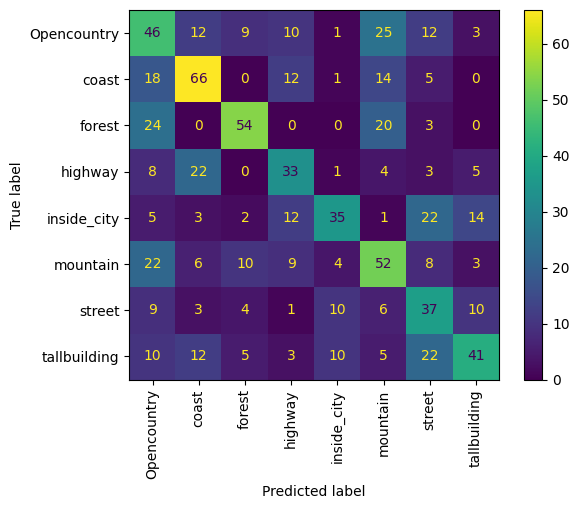

              precision    recall  f1-score   support

 Opencountry       0.32      0.39      0.35       118
       coast       0.53      0.57      0.55       116
      forest       0.64      0.53      0.58       101
     highway       0.41      0.43      0.42        76
 inside_city       0.56      0.37      0.45        94
    mountain       0.41      0.46      0.43       114
      street       0.33      0.46      0.39        80
tallbuilding       0.54      0.38      0.45       108

    accuracy                           0.45       807
   macro avg       0.47      0.45      0.45       807
weighted avg       0.47      0.45      0.45       807

0.44978380292712716
Running KNN with k=64, n_neighbors=1 amd metric=cosine...
Training model with KNeighborsClassifier...
Number of clusters: 64
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


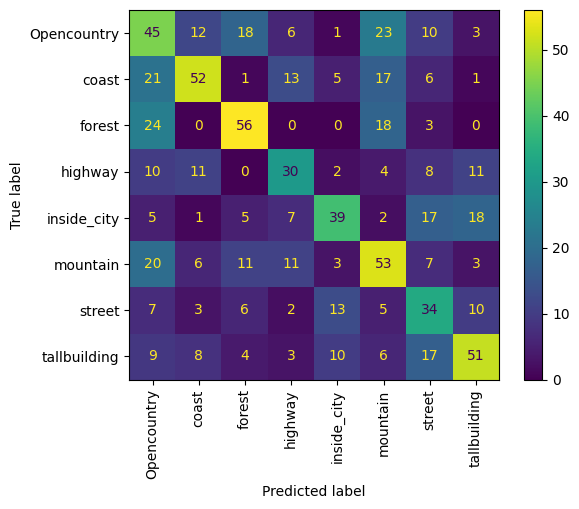

              precision    recall  f1-score   support

 Opencountry       0.32      0.38      0.35       118
       coast       0.56      0.45      0.50       116
      forest       0.55      0.55      0.55       101
     highway       0.42      0.39      0.41        76
 inside_city       0.53      0.41      0.47        94
    mountain       0.41      0.46      0.44       114
      street       0.33      0.42      0.37        80
tallbuilding       0.53      0.47      0.50       108

    accuracy                           0.45       807
   macro avg       0.46      0.44      0.45       807
weighted avg       0.46      0.45      0.45       807

0.44448152523342827
Running KNN with k=64, n_neighbors=1 amd metric=minkowski...
Training model with KNeighborsClassifier...
Number of clusters: 64
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


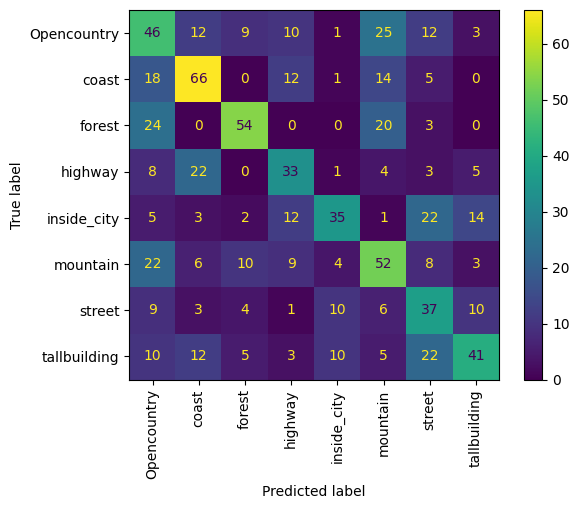

              precision    recall  f1-score   support

 Opencountry       0.32      0.39      0.35       118
       coast       0.53      0.57      0.55       116
      forest       0.64      0.53      0.58       101
     highway       0.41      0.43      0.42        76
 inside_city       0.56      0.37      0.45        94
    mountain       0.41      0.46      0.43       114
      street       0.33      0.46      0.39        80
tallbuilding       0.54      0.38      0.45       108

    accuracy                           0.45       807
   macro avg       0.47      0.45      0.45       807
weighted avg       0.47      0.45      0.45       807

0.44978380292712716
Running KNN with k=64, n_neighbors=3 amd metric=euclidean...
Training model with KNeighborsClassifier...
Number of clusters: 64
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


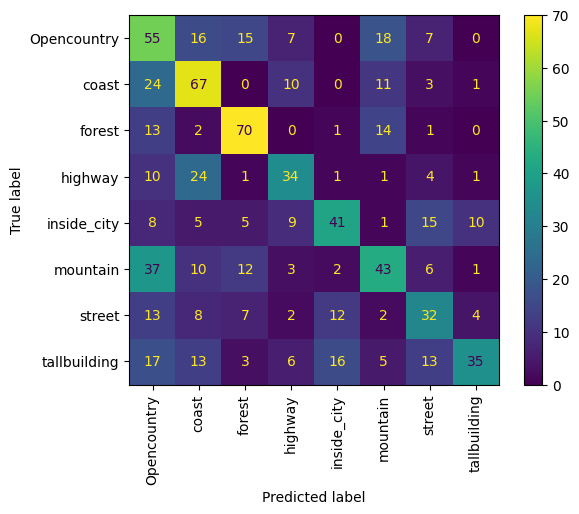

              precision    recall  f1-score   support

 Opencountry       0.31      0.47      0.37       118
       coast       0.46      0.58      0.51       116
      forest       0.62      0.69      0.65       101
     highway       0.48      0.45      0.46        76
 inside_city       0.56      0.44      0.49        94
    mountain       0.45      0.38      0.41       114
      street       0.40      0.40      0.40        80
tallbuilding       0.67      0.32      0.44       108

    accuracy                           0.47       807
   macro avg       0.49      0.47      0.47       807
weighted avg       0.49      0.47      0.47       807

0.4651953623864128
Running KNN with k=64, n_neighbors=3 amd metric=cosine...
Training model with KNeighborsClassifier...
Number of clusters: 64
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


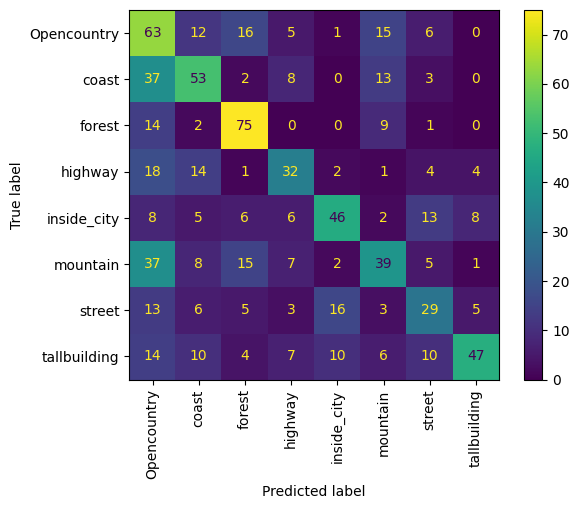

              precision    recall  f1-score   support

 Opencountry       0.31      0.53      0.39       118
       coast       0.48      0.46      0.47       116
      forest       0.60      0.74      0.67       101
     highway       0.47      0.42      0.44        76
 inside_city       0.60      0.49      0.54        94
    mountain       0.44      0.34      0.39       114
      street       0.41      0.36      0.38        80
tallbuilding       0.72      0.44      0.54       108

    accuracy                           0.48       807
   macro avg       0.50      0.47      0.48       807
weighted avg       0.50      0.48      0.48       807

0.47294673703553913
Running KNN with k=64, n_neighbors=3 amd metric=minkowski...
Training model with KNeighborsClassifier...
Number of clusters: 64
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


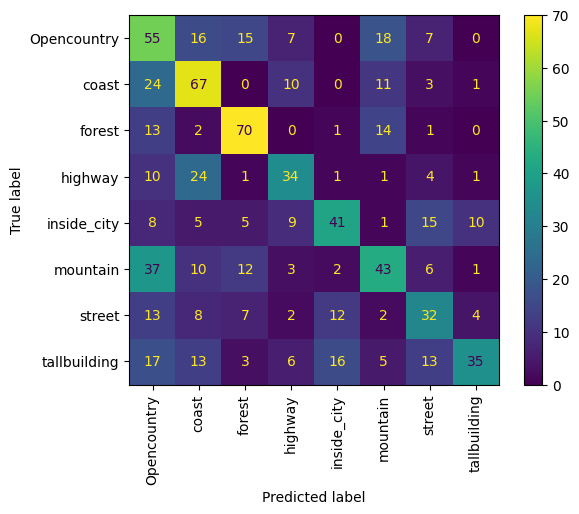

              precision    recall  f1-score   support

 Opencountry       0.31      0.47      0.37       118
       coast       0.46      0.58      0.51       116
      forest       0.62      0.69      0.65       101
     highway       0.48      0.45      0.46        76
 inside_city       0.56      0.44      0.49        94
    mountain       0.45      0.38      0.41       114
      street       0.40      0.40      0.40        80
tallbuilding       0.67      0.32      0.44       108

    accuracy                           0.47       807
   macro avg       0.49      0.47      0.47       807
weighted avg       0.49      0.47      0.47       807

0.4651953623864128
Running KNN with k=64, n_neighbors=5 amd metric=euclidean...
Training model with KNeighborsClassifier...
Number of clusters: 64
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


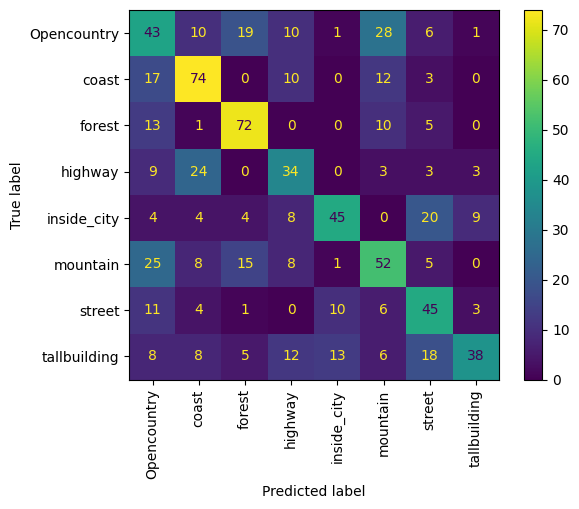

              precision    recall  f1-score   support

 Opencountry       0.33      0.36      0.35       118
       coast       0.56      0.64      0.59       116
      forest       0.62      0.71      0.66       101
     highway       0.41      0.45      0.43        76
 inside_city       0.64      0.48      0.55        94
    mountain       0.44      0.46      0.45       114
      street       0.43      0.56      0.49        80
tallbuilding       0.70      0.35      0.47       108

    accuracy                           0.50       807
   macro avg       0.52      0.50      0.50       807
weighted avg       0.52      0.50      0.50       807

0.5014741411636855
Running KNN with k=64, n_neighbors=5 amd metric=cosine...
Training model with KNeighborsClassifier...
Number of clusters: 64
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


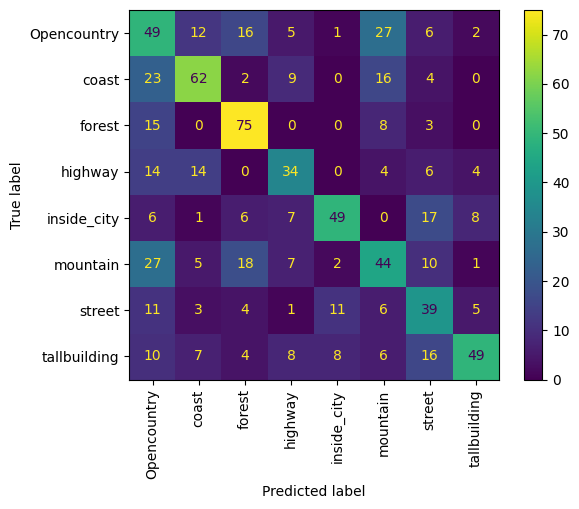

              precision    recall  f1-score   support

 Opencountry       0.32      0.42      0.36       118
       coast       0.60      0.53      0.56       116
      forest       0.60      0.74      0.66       101
     highway       0.48      0.45      0.46        76
 inside_city       0.69      0.52      0.59        94
    mountain       0.40      0.39      0.39       114
      street       0.39      0.49      0.43        80
tallbuilding       0.71      0.45      0.55       108

    accuracy                           0.50       807
   macro avg       0.52      0.50      0.50       807
weighted avg       0.52      0.50      0.50       807

0.49851561076453577
Running KNN with k=64, n_neighbors=5 amd metric=minkowski...
Training model with KNeighborsClassifier...
Number of clusters: 64
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


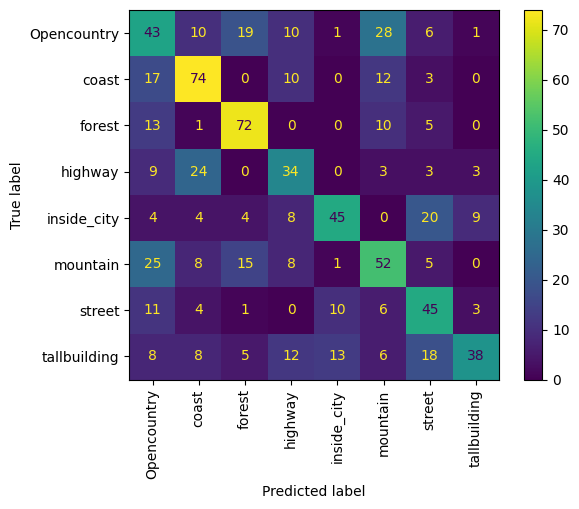

              precision    recall  f1-score   support

 Opencountry       0.33      0.36      0.35       118
       coast       0.56      0.64      0.59       116
      forest       0.62      0.71      0.66       101
     highway       0.41      0.45      0.43        76
 inside_city       0.64      0.48      0.55        94
    mountain       0.44      0.46      0.45       114
      street       0.43      0.56      0.49        80
tallbuilding       0.70      0.35      0.47       108

    accuracy                           0.50       807
   macro avg       0.52      0.50      0.50       807
weighted avg       0.52      0.50      0.50       807

0.5014741411636855
Running KNN with k=128, n_neighbors=1 amd metric=euclidean...
Training model with KNeighborsClassifier...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


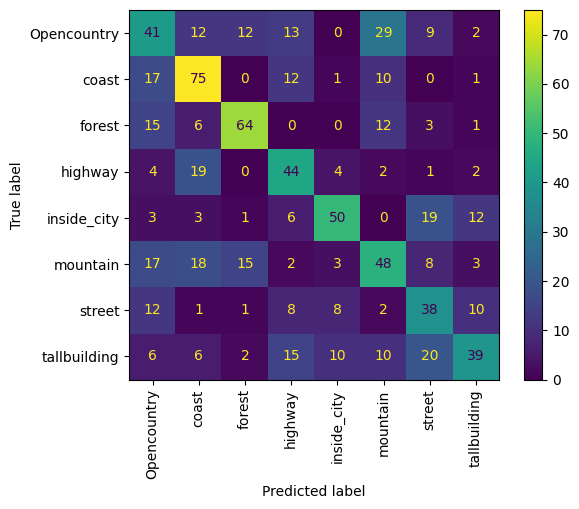

              precision    recall  f1-score   support

 Opencountry       0.36      0.35      0.35       118
       coast       0.54      0.65      0.59       116
      forest       0.67      0.63      0.65       101
     highway       0.44      0.58      0.50        76
 inside_city       0.66      0.53      0.59        94
    mountain       0.42      0.42      0.42       114
      street       0.39      0.47      0.43        80
tallbuilding       0.56      0.36      0.44       108

    accuracy                           0.49       807
   macro avg       0.50      0.50      0.50       807
weighted avg       0.50      0.49      0.49       807

0.4994623402901677
Running KNN with k=128, n_neighbors=1 amd metric=cosine...
Training model with KNeighborsClassifier...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


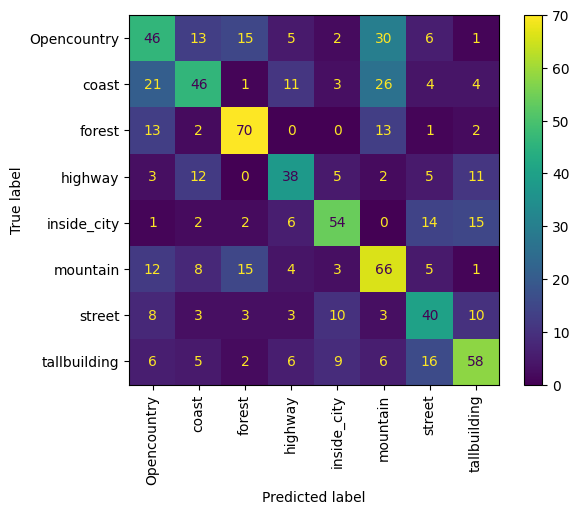

              precision    recall  f1-score   support

 Opencountry       0.42      0.39      0.40       118
       coast       0.51      0.40      0.44       116
      forest       0.65      0.69      0.67       101
     highway       0.52      0.50      0.51        76
 inside_city       0.63      0.57      0.60        94
    mountain       0.45      0.58      0.51       114
      street       0.44      0.50      0.47        80
tallbuilding       0.57      0.54      0.55       108

    accuracy                           0.52       807
   macro avg       0.52      0.52      0.52       807
weighted avg       0.52      0.52      0.52       807

0.5212380037634592
Running KNN with k=128, n_neighbors=1 amd metric=minkowski...
Training model with KNeighborsClassifier...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


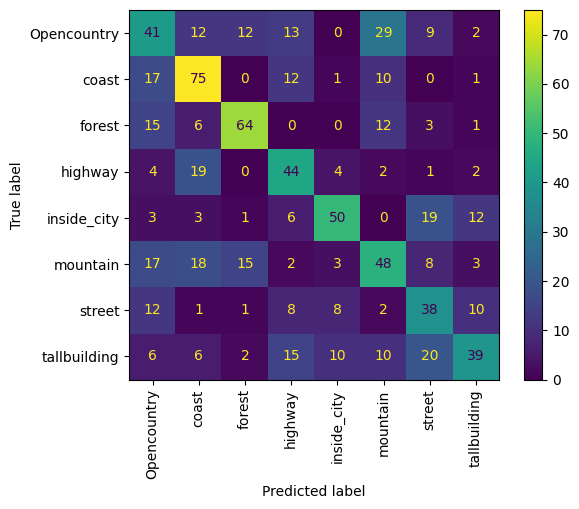

              precision    recall  f1-score   support

 Opencountry       0.36      0.35      0.35       118
       coast       0.54      0.65      0.59       116
      forest       0.67      0.63      0.65       101
     highway       0.44      0.58      0.50        76
 inside_city       0.66      0.53      0.59        94
    mountain       0.42      0.42      0.42       114
      street       0.39      0.47      0.43        80
tallbuilding       0.56      0.36      0.44       108

    accuracy                           0.49       807
   macro avg       0.50      0.50      0.50       807
weighted avg       0.50      0.49      0.49       807

0.4994623402901677
Running KNN with k=128, n_neighbors=3 amd metric=euclidean...
Training model with KNeighborsClassifier...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


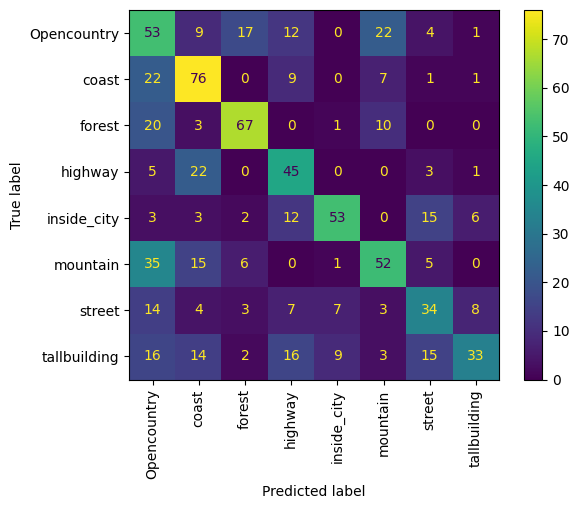

              precision    recall  f1-score   support

 Opencountry       0.32      0.45      0.37       118
       coast       0.52      0.66      0.58       116
      forest       0.69      0.66      0.68       101
     highway       0.45      0.59      0.51        76
 inside_city       0.75      0.56      0.64        94
    mountain       0.54      0.46      0.49       114
      street       0.44      0.42      0.43        80
tallbuilding       0.66      0.31      0.42       108

    accuracy                           0.51       807
   macro avg       0.54      0.51      0.52       807
weighted avg       0.54      0.51      0.51       807

0.5137902812030417
Running KNN with k=128, n_neighbors=3 amd metric=cosine...
Training model with KNeighborsClassifier...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


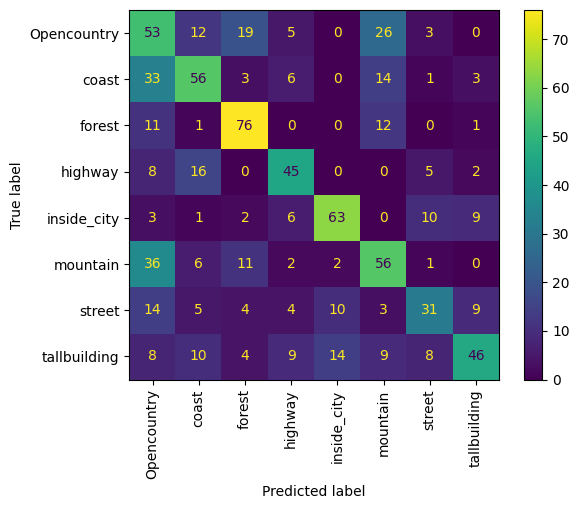

              precision    recall  f1-score   support

 Opencountry       0.32      0.45      0.37       118
       coast       0.52      0.48      0.50       116
      forest       0.64      0.75      0.69       101
     highway       0.58      0.59      0.59        76
 inside_city       0.71      0.67      0.69        94
    mountain       0.47      0.49      0.48       114
      street       0.53      0.39      0.45        80
tallbuilding       0.66      0.43      0.52       108

    accuracy                           0.53       807
   macro avg       0.55      0.53      0.54       807
weighted avg       0.55      0.53      0.53       807

0.5314198044754994
Running KNN with k=128, n_neighbors=3 amd metric=minkowski...
Training model with KNeighborsClassifier...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


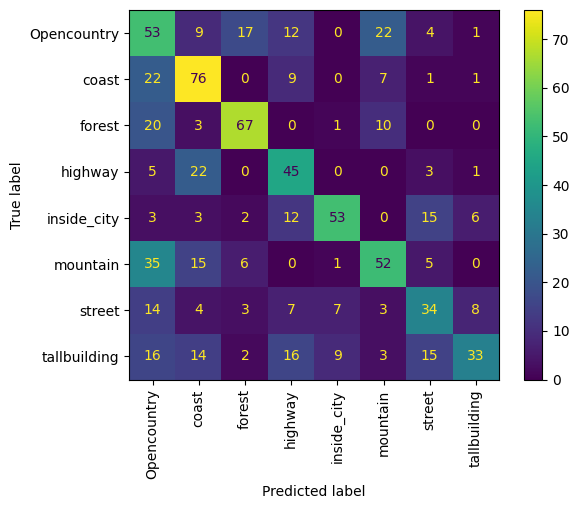

              precision    recall  f1-score   support

 Opencountry       0.32      0.45      0.37       118
       coast       0.52      0.66      0.58       116
      forest       0.69      0.66      0.68       101
     highway       0.45      0.59      0.51        76
 inside_city       0.75      0.56      0.64        94
    mountain       0.54      0.46      0.49       114
      street       0.44      0.42      0.43        80
tallbuilding       0.66      0.31      0.42       108

    accuracy                           0.51       807
   macro avg       0.54      0.51      0.52       807
weighted avg       0.54      0.51      0.51       807

0.5137902812030417
Running KNN with k=128, n_neighbors=5 amd metric=euclidean...
Training model with KNeighborsClassifier...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


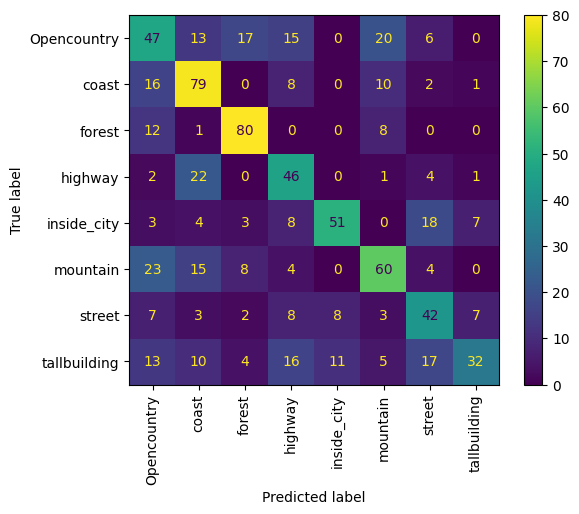

              precision    recall  f1-score   support

 Opencountry       0.38      0.40      0.39       118
       coast       0.54      0.68      0.60       116
      forest       0.70      0.79      0.74       101
     highway       0.44      0.61      0.51        76
 inside_city       0.73      0.54      0.62        94
    mountain       0.56      0.53      0.54       114
      street       0.45      0.53      0.49        80
tallbuilding       0.67      0.30      0.41       108

    accuracy                           0.54       807
   macro avg       0.56      0.55      0.54       807
weighted avg       0.56      0.54      0.54       807

0.5458559013224068
Running KNN with k=128, n_neighbors=5 amd metric=cosine...
Training model with KNeighborsClassifier...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


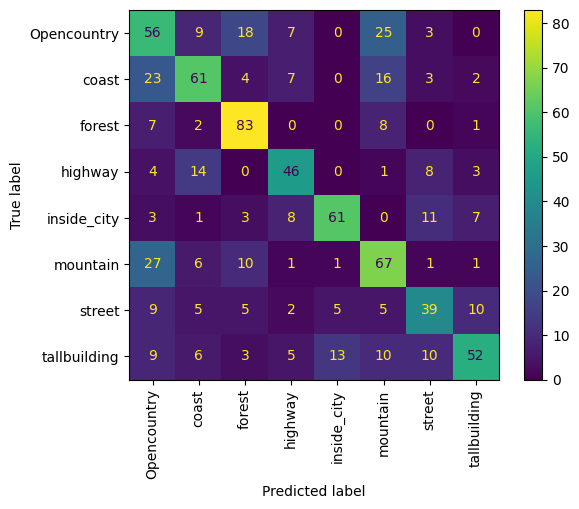

              precision    recall  f1-score   support

 Opencountry       0.41      0.47      0.44       118
       coast       0.59      0.53      0.55       116
      forest       0.66      0.82      0.73       101
     highway       0.61      0.61      0.61        76
 inside_city       0.76      0.65      0.70        94
    mountain       0.51      0.59      0.54       114
      street       0.52      0.49      0.50        80
tallbuilding       0.68      0.48      0.57       108

    accuracy                           0.58       807
   macro avg       0.59      0.58      0.58       807
weighted avg       0.59      0.58      0.58       807

0.5791400782755471
Running KNN with k=128, n_neighbors=5 amd metric=minkowski...
Training model with KNeighborsClassifier...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


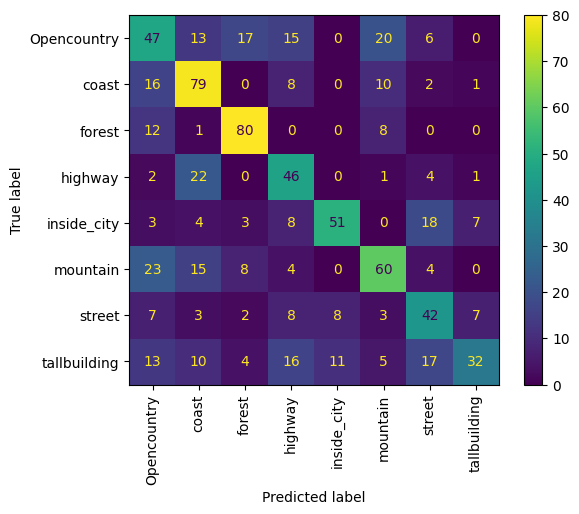

              precision    recall  f1-score   support

 Opencountry       0.38      0.40      0.39       118
       coast       0.54      0.68      0.60       116
      forest       0.70      0.79      0.74       101
     highway       0.44      0.61      0.51        76
 inside_city       0.73      0.54      0.62        94
    mountain       0.56      0.53      0.54       114
      street       0.45      0.53      0.49        80
tallbuilding       0.67      0.30      0.41       108

    accuracy                           0.54       807
   macro avg       0.56      0.55      0.54       807
weighted avg       0.56      0.54      0.54       807

0.5458559013224068
Running KNN with k=256, n_neighbors=1 amd metric=euclidean...
Training model with KNeighborsClassifier...
Number of clusters: 256
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


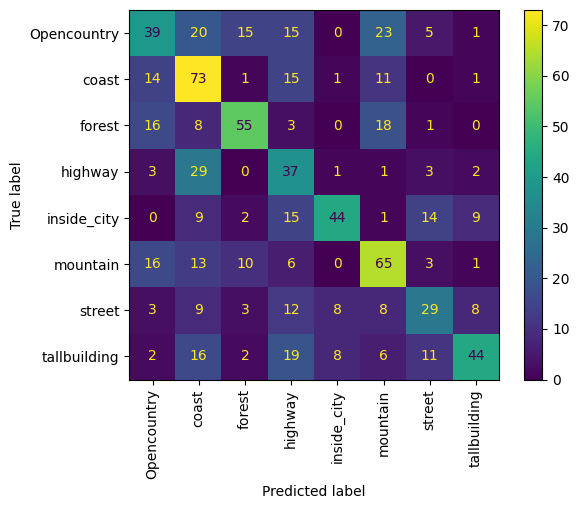

              precision    recall  f1-score   support

 Opencountry       0.42      0.33      0.37       118
       coast       0.41      0.63      0.50       116
      forest       0.62      0.54      0.58       101
     highway       0.30      0.49      0.37        76
 inside_city       0.71      0.47      0.56        94
    mountain       0.49      0.57      0.53       114
      street       0.44      0.36      0.40        80
tallbuilding       0.67      0.41      0.51       108

    accuracy                           0.48       807
   macro avg       0.51      0.47      0.48       807
weighted avg       0.51      0.48      0.48       807

0.4749229165624297
Running KNN with k=256, n_neighbors=1 amd metric=cosine...
Training model with KNeighborsClassifier...
Number of clusters: 256
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


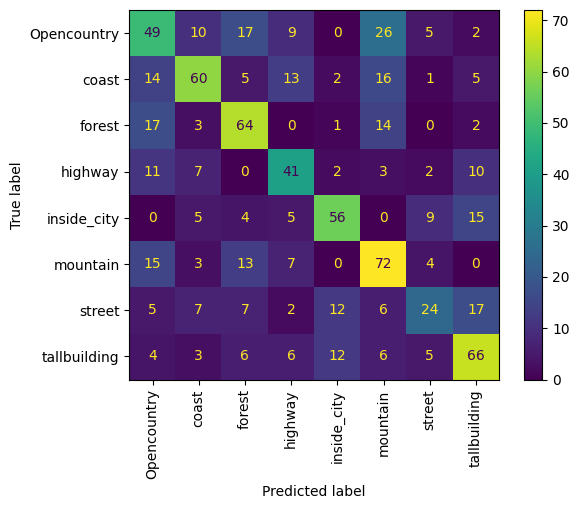

              precision    recall  f1-score   support

 Opencountry       0.43      0.42      0.42       118
       coast       0.61      0.52      0.56       116
      forest       0.55      0.63      0.59       101
     highway       0.49      0.54      0.52        76
 inside_city       0.66      0.60      0.63        94
    mountain       0.50      0.63      0.56       114
      street       0.48      0.30      0.37        80
tallbuilding       0.56      0.61      0.59       108

    accuracy                           0.54       807
   macro avg       0.54      0.53      0.53       807
weighted avg       0.54      0.54      0.53       807

0.5305084258095296
Running KNN with k=256, n_neighbors=1 amd metric=minkowski...
Training model with KNeighborsClassifier...
Number of clusters: 256
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


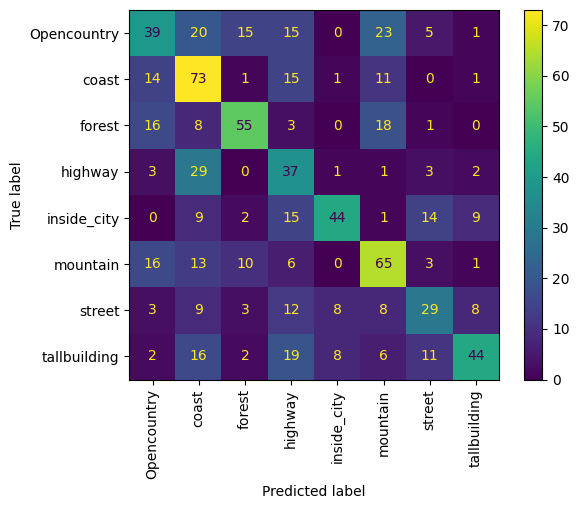

              precision    recall  f1-score   support

 Opencountry       0.42      0.33      0.37       118
       coast       0.41      0.63      0.50       116
      forest       0.62      0.54      0.58       101
     highway       0.30      0.49      0.37        76
 inside_city       0.71      0.47      0.56        94
    mountain       0.49      0.57      0.53       114
      street       0.44      0.36      0.40        80
tallbuilding       0.67      0.41      0.51       108

    accuracy                           0.48       807
   macro avg       0.51      0.47      0.48       807
weighted avg       0.51      0.48      0.48       807

0.4749229165624297
Running KNN with k=256, n_neighbors=3 amd metric=euclidean...
Training model with KNeighborsClassifier...
Number of clusters: 256
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


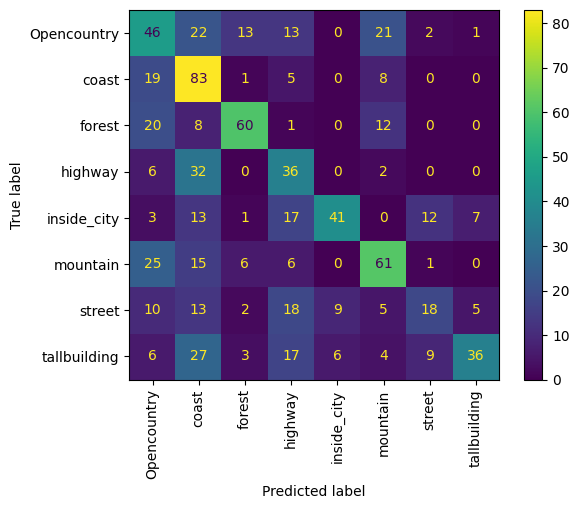

              precision    recall  f1-score   support

 Opencountry       0.34      0.39      0.36       118
       coast       0.39      0.72      0.50       116
      forest       0.70      0.59      0.64       101
     highway       0.32      0.47      0.38        76
 inside_city       0.73      0.44      0.55        94
    mountain       0.54      0.54      0.54       114
      street       0.43      0.23      0.30        80
tallbuilding       0.73      0.33      0.46       108

    accuracy                           0.47       807
   macro avg       0.52      0.46      0.47       807
weighted avg       0.53      0.47      0.47       807

0.46283532896479157
Running KNN with k=256, n_neighbors=3 amd metric=cosine...
Training model with KNeighborsClassifier...
Number of clusters: 256
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


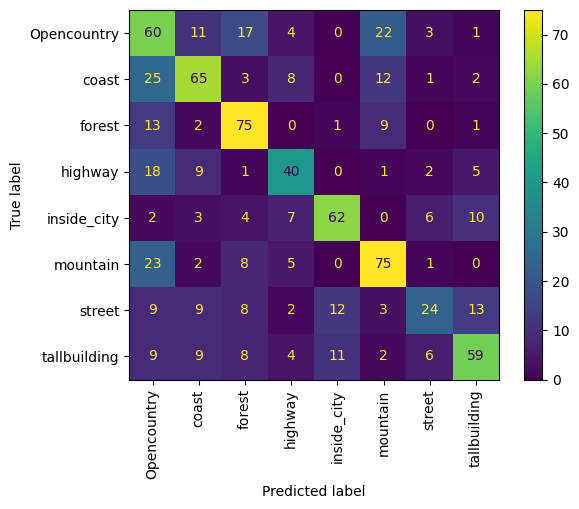

              precision    recall  f1-score   support

 Opencountry       0.38      0.51      0.43       118
       coast       0.59      0.56      0.58       116
      forest       0.60      0.74      0.67       101
     highway       0.57      0.53      0.55        76
 inside_city       0.72      0.66      0.69        94
    mountain       0.60      0.66      0.63       114
      street       0.56      0.30      0.39        80
tallbuilding       0.65      0.55      0.59       108

    accuracy                           0.57       807
   macro avg       0.58      0.56      0.57       807
weighted avg       0.58      0.57      0.57       807

0.5626843689975409
Running KNN with k=256, n_neighbors=3 amd metric=minkowski...
Training model with KNeighborsClassifier...
Number of clusters: 256
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


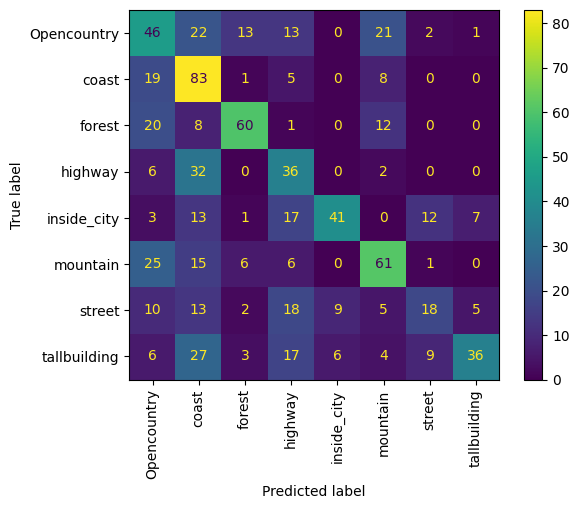

              precision    recall  f1-score   support

 Opencountry       0.34      0.39      0.36       118
       coast       0.39      0.72      0.50       116
      forest       0.70      0.59      0.64       101
     highway       0.32      0.47      0.38        76
 inside_city       0.73      0.44      0.55        94
    mountain       0.54      0.54      0.54       114
      street       0.43      0.23      0.30        80
tallbuilding       0.73      0.33      0.46       108

    accuracy                           0.47       807
   macro avg       0.52      0.46      0.47       807
weighted avg       0.53      0.47      0.47       807

0.46283532896479157
Running KNN with k=256, n_neighbors=5 amd metric=euclidean...
Training model with KNeighborsClassifier...
Number of clusters: 256
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


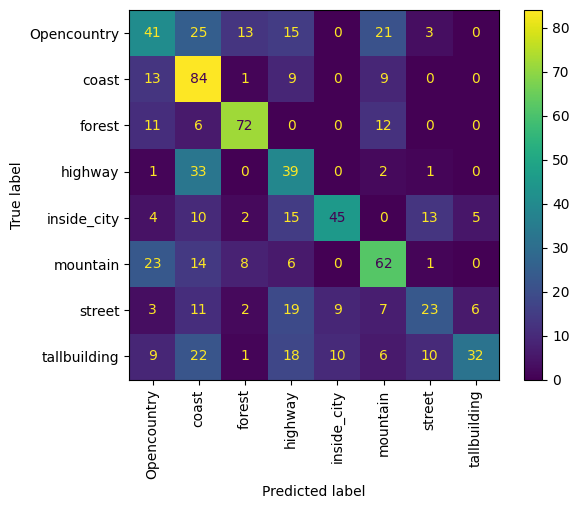

              precision    recall  f1-score   support

 Opencountry       0.39      0.35      0.37       118
       coast       0.41      0.72      0.52       116
      forest       0.73      0.71      0.72       101
     highway       0.32      0.51      0.40        76
 inside_city       0.70      0.48      0.57        94
    mountain       0.52      0.54      0.53       114
      street       0.45      0.29      0.35        80
tallbuilding       0.74      0.30      0.42       108

    accuracy                           0.49       807
   macro avg       0.53      0.49      0.49       807
weighted avg       0.54      0.49      0.49       807

0.488000511211638
Running KNN with k=256, n_neighbors=5 amd metric=cosine...
Training model with KNeighborsClassifier...
Number of clusters: 256
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


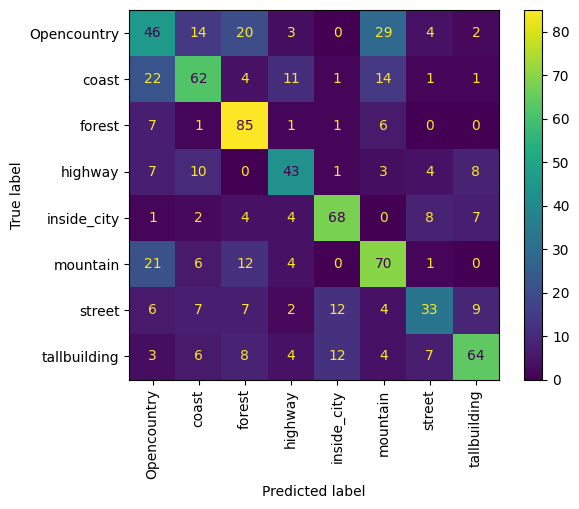

              precision    recall  f1-score   support

 Opencountry       0.41      0.39      0.40       118
       coast       0.57      0.53      0.55       116
      forest       0.61      0.84      0.71       101
     highway       0.60      0.57      0.58        76
 inside_city       0.72      0.72      0.72        94
    mountain       0.54      0.61      0.57       114
      street       0.57      0.41      0.48        80
tallbuilding       0.70      0.59      0.64       108

    accuracy                           0.58       807
   macro avg       0.59      0.58      0.58       807
weighted avg       0.58      0.58      0.58       807

0.5842773543532946
Running KNN with k=256, n_neighbors=5 amd metric=minkowski...
Training model with KNeighborsClassifier...
Number of clusters: 256
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: None
Using SIFT detector mode: keypoints_detection


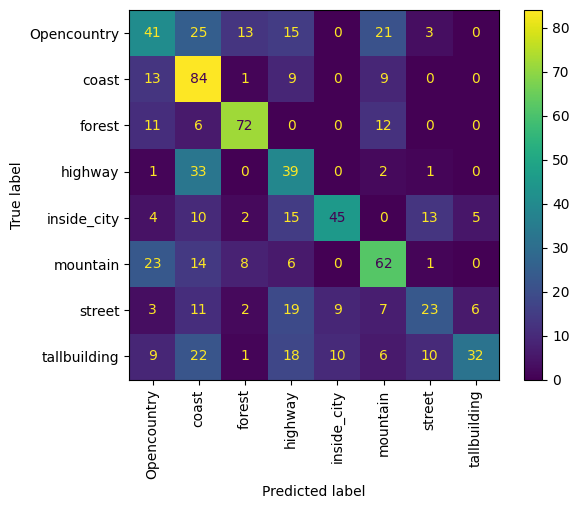

              precision    recall  f1-score   support

 Opencountry       0.39      0.35      0.37       118
       coast       0.41      0.72      0.52       116
      forest       0.73      0.71      0.72       101
     highway       0.32      0.51      0.40        76
 inside_city       0.70      0.48      0.57        94
    mountain       0.52      0.54      0.53       114
      street       0.45      0.29      0.35        80
tallbuilding       0.74      0.30      0.42       108

    accuracy                           0.49       807
   macro avg       0.53      0.49      0.49       807
weighted avg       0.54      0.49      0.49       807

0.488000511211638


In [56]:
train_filenames, test_filenames, train_labels, test_labels = load_files()
SIFTdetector = cv2.SIFT_create(300)
Train_descriptors, D = compute_SIFT_descriptors(train_filenames, train_labels, SIFTdetector, 'keypoints_detection')
for k in [64, 128, 256]:
    for knn_n in [1, 3, 5]:
        for metric in ['euclidean', 'cosine', 'minkowski']:
            print(f"Running KNN with k={k}, n_neighbors={knn_n} amd metric={metric}...")
            knn = KNeighborsClassifier(n_neighbors=knn_n,n_jobs=-1,metric=metric)
            run_model(knn, D, k, Train_descriptors, train_labels, test_filenames, test_labels, None , SIFTdetector, 'keypoints_detection')

<font color=white>The following table prints the results of the grid search</font><br>
| Codebook | k-NN | Metric    | Accuracy | Balanced Acc |
|----------|------|-----------|----------|--------------|
| 256      | 5    | cosine    | 0.58     | 0.58         |
| 128      | 5    | cosine    | 0.58     | 0.58         |
| 256      | 3    | cosine    | 0.57     | 0.56         |
| 128      | 5    | euclidean | 0.54     | 0.55         |
| 128      | 5    | minkowski | 0.54     | 0.55         |
| 256      | 1    | cosine    | 0.54     | 0.53         |
| 128      | 3    | cosine    | 0.53     | 0.53         |
| 128      | 1    | cosine    | 0.52     | 0.52         |
| 128      | 3    | euclidean | 0.51     | 0.51         |
| 128      | 3    | minkowski | 0.51     | 0.51         |
| 64       | 5    | euclidean | 0.50     | 0.50         |
| 64       | 5    | cosine    | 0.50     | 0.50         |
| 64       | 5    | minkowski | 0.50     | 0.50         |
| 256      | 5    | euclidean | 0.49     | 0.49         |
| 256      | 5    | minkowski | 0.49     | 0.49         |
| 128      | 1    | euclidean | 0.49     | 0.50         |
| 128      | 1    | minkowski | 0.49     | 0.50         |
| 256      | 1    | euclidean | 0.48     | 0.47         |
| 256      | 1    | minkowski | 0.48     | 0.47         |
| 64       | 3    | cosine    | 0.48     | 0.47         |
| 64       | 3    | euclidean | 0.47     | 0.47         |
| 64       | 3    | minkowski | 0.47     | 0.47         |
| 256      | 3    | euclidean | 0.47     | 0.46         |
| 256      | 3    | minkowski | 0.47     | 0.46         |
| 64       | 1    | euclidean | 0.45     | 0.45         |
| 64       | 1    | cosine    | 0.45     | 0.44         |
| 64       | 1    | minkowski | 0.45     | 0.45         |

As we can see the best results are obtained using cosine distance metric with 5 clusters and 256 vocabulary size. Additonally, we get the same accuracy with 128 vocabulary size and 0.57 with 256 vocab size, number of neighbours=3 and also cosine distance.
Finally, we can see that overall, the worst classified classes are *Street* which is usually confused with highway, inside_city and Tallbuildings;*Opencountry* confused with Mountain and forest; and *Highway*  with street, coast and tallbuilings.


<font color=red>3. Use a linear SVM classifier. Use sklearn `StandardScaler` to standardize features (removing the mean and scaling to unit variance).</font><br>

Training model with SVC...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: StandardScaler
Using SIFT detector mode: keypoints_detection


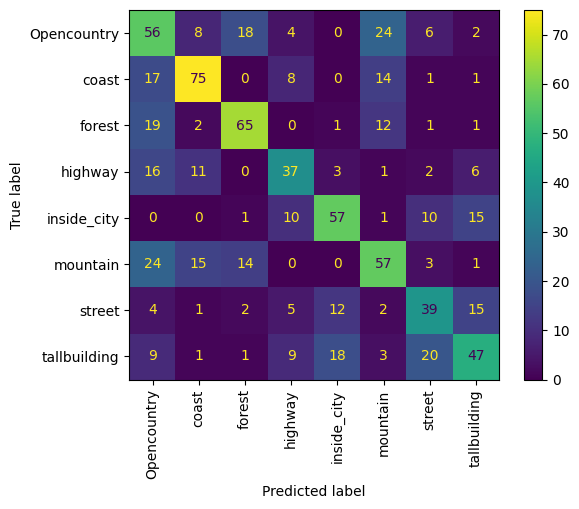

              precision    recall  f1-score   support

 Opencountry       0.39      0.47      0.43       118
       coast       0.66      0.65      0.66       116
      forest       0.64      0.64      0.64       101
     highway       0.51      0.49      0.50        76
 inside_city       0.63      0.61      0.62        94
    mountain       0.50      0.50      0.50       114
      street       0.48      0.49      0.48        80
tallbuilding       0.53      0.44      0.48       108

    accuracy                           0.54       807
   macro avg       0.54      0.54      0.54       807
weighted avg       0.54      0.54      0.54       807

0.5350753276164704


In [57]:
# Your code here to compute the codebook and histograms for training images
train_filenames, test_filenames, train_labels, test_labels = load_files()
SIFTdetector = cv2.SIFT_create(300)
descriptors, D = compute_SIFT_descriptors(filenames, train_labels, SIFTdetector, 'keypoints_detection')
svm = SVC(kernel='linear')
scaler = StandardScaler()
run_model(svm, D, 128, Train_descriptors, train_labels, test_filenames, test_labels, scaler,SIFTdetector, 'keypoints_detection')

<font color=white>
As we can see we get a performance of 53,5% accuracy which is lower than the best model we obtained using k nearest neghbours. However, this is done using a linear kernel and without finding the best hyperparameters. The best classified classes are *Coast*, *Forest* and *Inside_city*. Also, the worst classified classes are *Street*, *Tallbuilding* and *Mountain*. 
</font><br>

<font color=red>4. (optional) Use another variant of SVM: (1) with RBF kernel, (2) with histogram intersection kernel.
Use sklearn `StandardScaler` to standardize features.</font><br>

Training model with SVC...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: StandardScaler
Using SIFT detector mode: keypoints_detection


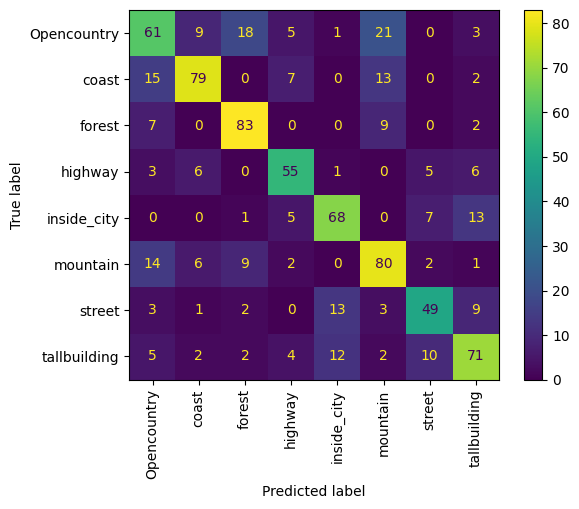

              precision    recall  f1-score   support

 Opencountry       0.56      0.52      0.54       118
       coast       0.77      0.68      0.72       116
      forest       0.72      0.82      0.77       101
     highway       0.71      0.72      0.71        76
 inside_city       0.72      0.72      0.72        94
    mountain       0.62      0.70      0.66       114
      street       0.67      0.61      0.64        80
tallbuilding       0.66      0.66      0.66       108

    accuracy                           0.68       807
   macro avg       0.68      0.68      0.68       807
weighted avg       0.68      0.68      0.68       807

0.6798145090920749


In [58]:
# Your code here to compute the codebook and histograms for training images
train_filenames, test_filenames, train_labels, test_labels = load_files()
SIFTdetector = cv2.SIFT_create(300)
descriptors, D = compute_SIFT_descriptors(filenames, train_labels, SIFTdetector, 'keypoints_detection')
svm = SVC(kernel='rbf')
scaler = StandardScaler()
run_model(svm, D, 128, Train_descriptors, train_labels, test_filenames, test_labels, scaler, SIFTdetector, 'keypoints_detection')

Training model with SVC...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: StandardScaler
Using SIFT detector mode: keypoints_detection


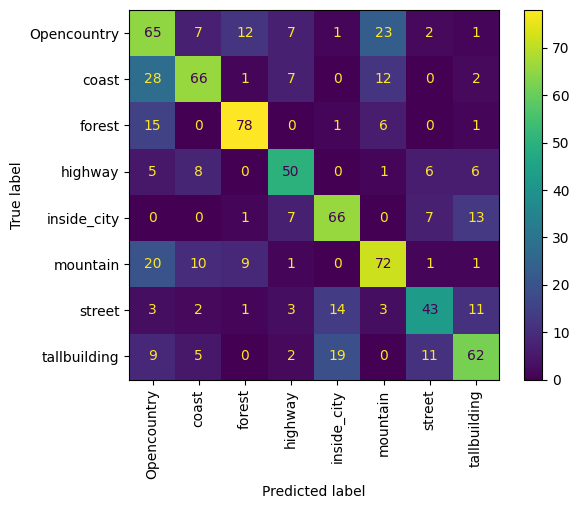

              precision    recall  f1-score   support

 Opencountry       0.45      0.55      0.49       118
       coast       0.67      0.57      0.62       116
      forest       0.76      0.77      0.77       101
     highway       0.65      0.66      0.65        76
 inside_city       0.65      0.70      0.68        94
    mountain       0.62      0.63      0.62       114
      street       0.61      0.54      0.57        80
tallbuilding       0.64      0.57      0.60       108

    accuracy                           0.62       807
   macro avg       0.63      0.62      0.63       807
weighted avg       0.63      0.62      0.62       807

0.6244082025562924


In [59]:
def histogram_intersection_kernel(X, Y=None):
    """
    Compute the histogram intersection kernel between X and Y.
    K(x, y) = sum(min(x_i, y_i))
    
    Parameters
    ----------
    X : array-like, shape (n_samples_X, n_features)
        First set of samples.
    Y : array-like, shape (n_samples_Y, n_features), optional
        Second set of samples. If None, Y=X.
    
    Returns
    -------
    K : array-like, shape (n_samples_X, n_samples_Y)
        Kernel matrix.
    """
    return pairwise_kernels(X, Y, metric=lambda x, y: np.sum(np.minimum(x, y)))

train_filenames, test_filenames, train_labels, test_labels = load_files()
SIFTdetector = cv2.SIFT_create(300)
descriptors, D = compute_SIFT_descriptors(filenames, train_labels, SIFTdetector, 'keypoints_detection')
svm = SVC(kernel=histogram_intersection_kernel)
scaler = StandardScaler()
run_model(svm, D, 128, Train_descriptors, train_labels, test_filenames, test_labels, scaler, SIFTdetector, 'keypoints_detection')

<font color=white>

# SVM with rbf kernel
As we can see we are obtaining an improvement with respect the kNN and the SVM with the linear kernel. We are achieving a 68% accuraccy. This is done as the kernel allows to capture non-linear relationships between visual words.*Forest* and *Inside_city* are still the best represented classes while *Opencountry* and *Street are the worst performant. We have higher accuracy in all classes.

# SVM with histogram intersection kernel
As we can see we are obtaining a 62% accuracy with *Forest* remains the best-performing class and *Opencountry* the worst. Although the rbf kernel shows better performance, we still have a better performance than the initial models

# Both
We have increased the performance of the model, however, further hyperparameter finetunning could be done in order to select the best model.

</font><br>

<font color=red>5. Use Dense SIFT instead of detected keypoints. Report your best results and compare with results using detected keypoints.</font><br>


Training model with SVC...
Number of clusters: 128
Number of training samples: 1881
Number of test samples: 807
Number of features: 128
Number of descriptors: 1881
Using scaler: StandardScaler
Using SIFT detector mode: dense


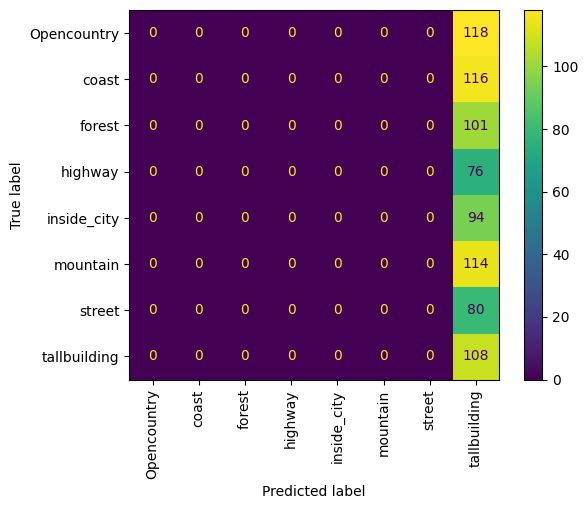

              precision    recall  f1-score   support

 Opencountry       0.00      0.00      0.00       118
       coast       0.00      0.00      0.00       116
      forest       0.00      0.00      0.00       101
     highway       0.00      0.00      0.00        76
 inside_city       0.00      0.00      0.00        94
    mountain       0.00      0.00      0.00       114
      street       0.00      0.00      0.00        80
tallbuilding       0.13      1.00      0.24       108

    accuracy                           0.13       807
   macro avg       0.02      0.12      0.03       807
weighted avg       0.02      0.13      0.03       807

0.125


c:\Users\enric\OneDrive\Documentos\Master\CVDL\Labs\cvdl-labs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\enric\OneDrive\Documentos\Master\CVDL\Labs\cvdl-labs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\enric\OneDrive\Documentos\Master\CVDL\Labs\cvdl-labs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control

In [60]:
# Your code here to compute the codebook and histograms for training images
train_filenames, test_filenames, train_labels, test_labels = load_files()
SIFTdetector = cv2.SIFT_create(300)
descriptors, D = compute_SIFT_descriptors(filenames, train_labels, SIFTdetector, 'dense')
svm = SVC(kernel='rbf')
scaler = StandardScaler()
run_model(svm, D, 128, Train_descriptors, train_labels, test_filenames, test_labels, scaler, SIFTdetector, 'dense')

<font color=white>
As we can see, when comparing the model with the only change of which points are selected to generate the feature descriptor we can see a huge decrease in performance. With dense mode, we are selecting key points by iterating by *step_size* instead of selecting points by detecting keypoints. This results in a poor performance where all the classes are classified as *Tallbuilding* which means that the model is not able to classify correcly any class, but assigning the same class to all predictions.
 </font><br>

<font color=blue>Conclusions:

Write a few paragraphs summarizing your work, results and conclussions from this assignment</font><br>

## Work
In this practise, we have studied how to classes for images using the *Bag of Visual Words* algorithm which consists on:
1. Extract descriptors for each image
2. Generate a bag of words using k-means algorithm to generate clusters (size of vocabulary) by grouping all the descriptors. Each center of a cluster is a visual word.
3. Project each descriptor to a cluster (word)
4. Generate a histogram with the counts of each word to generate a feature vector
5. Fit the data using a classifier with the given feature vector and label

Additionally, we have analyzed the performance of different models where we changed the classifier and find best hyperparameters. 
Finally, we have seen the importance of selecting points to generate descriptors

## Results and conclusions
We have seen that from the different models, the best performance achieved was 68% accuracy using a SVM with an rbf kernel with keypoints detection. Additionally, we have seen that using kNN classifier we have seen that we achieve up to 58% accuracy. Finally, we have seen that when using a DENSE Sift detector, the perfomance decreased to 12.5% accuracy, however, the real performance is 0 as it classified all the samples to the same label 
